<a href="https://colab.research.google.com/github/sk27110/DL2/blob/HW1/HW1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from tqdm.auto import tqdm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

os.makedirs("results", exist_ok=True)


In [ ]:
DATA = "cifar10"
ROOT = "./my_data"

EPOCHS = 10
BATCH_SIZE = 128
IMG_SIZE = 32
LR = 3e-4
WEIGHT_DECAY = 0.05
NUM_WORKERS = 2
SEED = 42

def seed_all(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"



В качестве датасета возьмем CIFAR-10, он маленький, и обучение моделей не займет много времени.

In [ ]:
def get_data(data="cifar10", root="./my_data", img_size=32, batch_size=128, workers=2):
    if data == "cifar10":
        train_tf = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomCrop(img_size, padding=4),
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
        ])

        val_tf = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
        ])

        train_ds = datasets.CIFAR10("./data", train=True, download=True, transform=train_tf)
        val_ds = datasets.CIFAR10("./data", train=False, download=True, transform=val_tf)
        classes = train_ds.classes

    else:
        train_tf = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])

        val_tf = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])

        train_ds = datasets.ImageFolder(os.path.join(root, "train"), transform=train_tf)
        val_ds = datasets.ImageFolder(os.path.join(root, "val"), transform=val_tf)
        classes = train_ds.classes

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=workers,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=workers,
        pin_memory=True
    )

    return train_loader, val_loader, classes


In [ ]:
train_loader, val_loader, classes = get_data(
    data=DATA,
    root=ROOT,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    workers=NUM_WORKERS
)

num_classes = len(classes)

print("classes:", classes)
print("num_classes:", num_classes)
print("train batches:", len(train_loader))
print("val batches:", len(val_loader))


classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
num_classes: 10
train batches: 391
val batches: 79


In [ ]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


class DropPath(nn.Module):
    def __init__(self, p=0.0):
        super().__init__()
        self.p = p

    def forward(self, x):
        if self.p == 0.0 or not self.training:
            return x

        keep = 1 - self.p
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        mask = torch.rand(shape, device=x.device) < keep
        return x.div(keep) * mask


Взять готовую реализацию модели у меня не получилось ввиду несовместимости версий библиотек, поэтому тут представлена упрощенная реализация, в которой реализована основная идея статьи.

In [ ]:
class PatchEmbed(nn.Module):
    def __init__(self, c1, c2, stride=2):
        super().__init__()
        self.proj = nn.Conv2d(c1, c2, kernel_size=3, stride=stride, padding=1)
        self.norm = nn.BatchNorm2d(c2)

    def forward(self, x):
        return self.norm(self.proj(x))


class MLP(nn.Module):
    def __init__(self, dim, ratio=4):
        super().__init__()
        hid = dim * ratio
        self.net = nn.Sequential(
            nn.Conv2d(dim, hid, kernel_size=1),
            nn.GELU(),
            nn.Conv2d(hid, dim, kernel_size=1)
        )

    def forward(self, x):
        return self.net(x)


class LayerNorm2d(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.norm = nn.LayerNorm(dim, eps=eps)

    def forward(self, x):
        # B,C,H,W -> B,H,W,C -> B,C,H,W
        x = x.permute(0, 2, 3, 1)
        x = self.norm(x)
        x = x.permute(0, 3, 1, 2)
        return x


class NCSSD2D(nn.Module):
    """
    Стабильная упрощенная версия Non-Causal SSD.

    Было:
        H = sum_j m_j * B_j * X_j

    Стало стабильнее:
        m = softmax(m) по токенам
        B = tanh(B)
        C = tanh(C)

    Это предотвращает взрыв значений и NaN в val_loss.
    """

    def __init__(self, dim, heads=4, state_dim=16):
        super().__init__()

        assert dim % heads == 0

        self.dim = dim
        self.heads = heads
        self.dh = dim // heads
        self.state_dim = state_dim

        self.in_norm = LayerNorm2d(dim)

        self.dwconv = nn.Conv2d(
            dim,
            dim,
            kernel_size=3,
            padding=1,
            groups=dim
        )

        self.to_x = nn.Conv2d(dim, dim, kernel_size=1)
        self.to_b = nn.Conv2d(dim, heads * state_dim, kernel_size=1)
        self.to_c = nn.Conv2d(dim, heads * state_dim, kernel_size=1)
        self.to_m = nn.Conv2d(dim, heads, kernel_size=1)

        self.out = nn.Conv2d(dim, dim, kernel_size=1)
        self.out_norm = LayerNorm2d(dim)

        self.gamma = nn.Parameter(torch.ones(1) * 0.1)

    def forward(self, x):
        bsz, dim, h, w = x.shape
        l = h * w

        u = self.in_norm(x)
        u = self.dwconv(u)

        xval = self.to_x(u).view(
            bsz,
            self.heads,
            self.dh,
            l
        )

        b = self.to_b(u).view(
            bsz,
            self.heads,
            self.state_dim,
            l
        )
        c = self.to_c(u).view(
            bsz,
            self.heads,
            self.state_dim,
            l
        )

        m = self.to_m(u).view(
            bsz,
            self.heads,
            l
        )

        b = torch.tanh(b)
        c = torch.tanh(c)
        m = torch.softmax(m, dim=-1)

        global_state = torch.einsum(
            "bhnl,bhdl,bhl->bhnd",
            b,
            xval,
            m
        )

        y = torch.einsum(
            "bhnl,bhnd->bhdl",
            c,
            global_state
        )

        y = y.reshape(bsz, dim, h, w)

        y = self.out(y)
        y = self.out_norm(y)

        return self.gamma * y


class VSSDBlock(nn.Module):
    def __init__(self, dim, heads=4, state_dim=16, drop=0.0):
        super().__init__()

        self.lpu1 = nn.Conv2d(dim, dim, kernel_size=3, padding=1, groups=dim)
        self.norm1 = nn.BatchNorm2d(dim)
        self.mix = NCSSD2D(dim, heads=heads, state_dim=state_dim)
        self.drop1 = DropPath(drop)

        self.lpu2 = nn.Conv2d(dim, dim, kernel_size=3, padding=1, groups=dim)
        self.norm2 = nn.BatchNorm2d(dim)
        self.mlp = MLP(dim)
        self.drop2 = DropPath(drop)

    def forward(self, x):
        x = x + self.drop1(self.mix(self.norm1(x + self.lpu1(x))))
        x = x + self.drop2(self.mlp(self.norm2(x + self.lpu2(x))))
        return x


class MiniVSSD(nn.Module):
    def __init__(
        self,
        num_classes=10,
        dims=(64, 128, 256),
        depths=(2, 2, 2),
        heads=4,
        state_dim=16
    ):
        super().__init__()

        self.stem = PatchEmbed(3, dims[0], stride=2)

        layers = []
        in_ch = dims[0]

        for stage_idx, dim in enumerate(dims):
            if stage_idx > 0:
                layers.append(PatchEmbed(in_ch, dim, stride=2))

            for _ in range(depths[stage_idx]):
                layers.append(VSSDBlock(
                    dim=dim,
                    heads=heads,
                    state_dim=state_dim
                ))

            in_ch = dim

        self.features = nn.Sequential(*layers)
        self.head = nn.Linear(dims[-1], num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.features(x)
        x = x.mean(dim=(2, 3))
        x = self.head(x)
        return x


В качестве аналога возьмем простую CNN с примерно таким же числом параметров, как у нашей модели

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10, width=96):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, width, kernel_size=3, padding=1),
            nn.BatchNorm2d(width),
            nn.ReLU(),

            nn.Conv2d(width, width, kernel_size=3, padding=1),
            nn.BatchNorm2d(width),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(width, width * 2, kernel_size=3, padding=1),
            nn.BatchNorm2d(width * 2),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(width * 2, width * 4, kernel_size=3, padding=1),
            nn.BatchNorm2d(width * 4),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(width * 4, width * 4, kernel_size=3, padding=1),
            nn.BatchNorm2d(width * 4),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d(1)
        )

        self.classifier = nn.Linear(width * 4, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        x = self.classifier(x)
        return x


In [ ]:
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()

    total = 0
    correct = 0
    loss_sum = 0

    y_true = []
    y_pred = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        out = model(x)
        loss = F.cross_entropy(out, y)

        pred = out.argmax(dim=1)

        total += y.size(0)
        correct += pred.eq(y).sum().item()
        loss_sum += loss.item() * y.size(0)

        y_true.extend(y.cpu().numpy())
        y_pred.extend(pred.cpu().numpy())

    avg_loss = loss_sum / total
    avg_acc = correct / total

    return avg_loss, avg_acc, np.array(y_true), np.array(y_pred)


def train_one(model, train_loader, val_loader, epochs, lr, weight_decay, device, name):
    model = model.to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs
    )

    history = []
    best_acc = 0.0
    start_time = time.time()

    for epoch in range(1, epochs + 1):
        model.train()

        train_loss_sum = 0.0
        train_correct = 0
        train_total = 0

        pbar = tqdm(train_loader, desc=f"{name} epoch {epoch}/{epochs}")

        for x, y in pbar:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad(set_to_none=True)

            out = model(x)
            loss = F.cross_entropy(out, y)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            optimizer.step()


            pred = out.argmax(dim=1)

            train_loss_sum += loss.item() * y.size(0)
            train_correct += pred.eq(y).sum().item()
            train_total += y.size(0)

            pbar.set_postfix({
                "loss": train_loss_sum / train_total,
                "acc": train_correct / train_total
            })

        scheduler.step()

        train_loss = train_loss_sum / train_total
        train_acc = train_correct / train_total

        val_loss, val_acc, _, _ = evaluate(model, val_loader, device)

        history.append({
            "model": name,
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc
        })

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), f"results/{name}_best.pt")

        print(
            f"{name}: epoch={epoch}, "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
            f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
        )

    elapsed = time.time() - start_time

    return pd.DataFrame(history), best_acc, elapsed


In [ ]:
def plot_history(df):
    os.makedirs("results", exist_ok=True)

    for metric in ["train_loss", "val_loss", "train_acc", "val_acc"]:
        plt.figure(figsize=(7, 4))

        for name in df["model"].unique():
            sub = df[df["model"] == name]
            plt.plot(sub["epoch"], sub[metric], marker="o", label=name)

        plt.title(metric)
        plt.xlabel("epoch")
        plt.ylabel(metric)
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.savefig(f"results/{metric}.png", dpi=160)
        plt.show()


def plot_cm(y_true, y_pred, classes, name):
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(8, 8))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=classes
    )

    disp.plot(
        ax=ax,
        xticks_rotation=45,
        cmap="Blues",
        colorbar=False
    )

    plt.title(f"Confusion matrix: {name}")
    plt.tight_layout()
    plt.savefig(f"results/cm_{name}.png", dpi=160)
    plt.show()


In [ ]:
models = {
    "MiniVSSD": MiniVSSD(num_classes=num_classes),
    "SimpleCNN": SimpleCNN(num_classes=num_classes)
}

In [ ]:
for name, model in models.items():
    print(name, "params:", count_params(model))

MiniVSSD params: 2253992
SimpleCNN params: 2249386


Обучаем VSSD

In [ ]:
model_name = "MiniVSSD"
model = models[model_name]

hist_vssd, best_vssd, time_vssd = train_one(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    device=device,
    name=model_name
)

print("best MiniVSSD val acc:", best_vssd)
print("training time:", time_vssd)


MiniVSSD epoch 1/10:   0%|          | 0/391 [00:00<?, ?it/s]

MiniVSSD: epoch=1, train_loss=1.5316, train_acc=0.4359, val_loss=1.3010, val_acc=0.5332


MiniVSSD epoch 2/10:   0%|          | 0/391 [00:00<?, ?it/s]

MiniVSSD: epoch=2, train_loss=1.1491, train_acc=0.5858, val_loss=1.0136, val_acc=0.6405


MiniVSSD epoch 3/10:   0%|          | 0/391 [00:00<?, ?it/s]

...

MiniVSSD: epoch=8, train_loss=0.5585, train_acc=0.8050, val_loss=0.6189, val_acc=0.7863


MiniVSSD epoch 9/10:   0%|          | 0/391 [00:00<?, ?it/s]

MiniVSSD: epoch=9, train_loss=0.5235, train_acc=0.8162, val_loss=0.6024, val_acc=0.7946


MiniVSSD epoch 10/10:   0%|          | 0/391 [00:00<?, ?it/s]

MiniVSSD: epoch=10, train_loss=0.5128, train_acc=0.8207, val_loss=0.5950, val_acc=0.7950
best MiniVSSD val acc: 0.795
training time: 530.4933893680573


Обучаем аналог

In [ ]:
model_name = "SimpleCNN"
model = models[model_name]

hist_cnn, best_cnn, time_cnn = train_one(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    device=device,
    name=model_name
)

print("best SimpleCNN val acc:", best_cnn)
print("training time:", time_cnn)


SimpleCNN epoch 1/10:   0%|          | 0/391 [00:00<?, ?it/s]

SimpleCNN: epoch=1, train_loss=1.2693, train_acc=0.5442, val_loss=1.2172, val_acc=0.5703


SimpleCNN epoch 2/10:   0%|          | 0/391 [00:00<?, ?it/s]

SimpleCNN: epoch=2, train_loss=0.8853, train_acc=0.6914, val_loss=1.0571, val_acc=0.6415


SimpleCNN epoch 3/10:   0%|          | 0/391 [00:00<?, ?it/s]

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e63fb2e4a40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionErrorcan only test a child process: 
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e63fb2e4a40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

SimpleCNN: epoch=9, train_loss=0.3739, train_acc=0.8735, val_loss=0.4430, val_acc=0.8516


SimpleCNN epoch 10/10:   0%|          | 0/391 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e63fb2e4a40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():Exception ignored in: Exception ignored in: 
<function _MultiProcessingDataLoaderIter.__del__ at 0x7e63fb2e4a40> <function _MultiProcessingDataLoaderIter.__del__ at 0x7e63fb2e4a40>

 Traceback (most recent call last):
Exception ignored in: Traceback (most recent call last):
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
<function _MultiProcessingDataLoaderIter.__del__ at 0x7e63fb2e4a40>  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
 
         Traceback (most recent call last):
self._shutdown_

SimpleCNN: epoch=10, train_loss=0.3517, train_acc=0.8813, val_loss=0.4302, val_acc=0.8548
best SimpleCNN val acc: 0.8548
training time: 286.96549558639526


MiniVSSD val loss: 0.5949857465744018
MiniVSSD val acc: 0.795


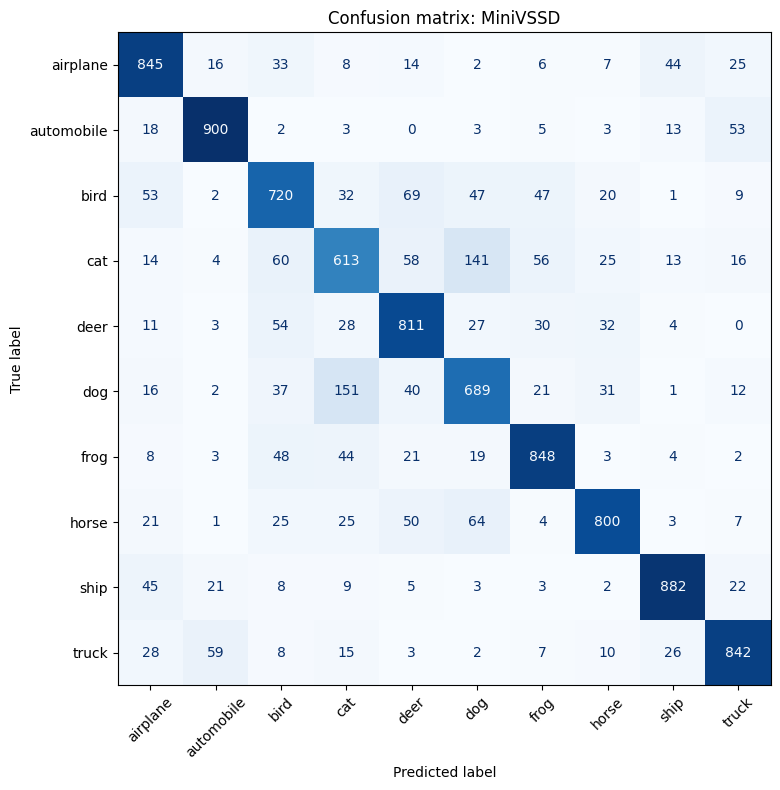

              precision    recall  f1-score   support

    airplane       0.80      0.84      0.82      1000
  automobile       0.89      0.90      0.90      1000
        bird       0.72      0.72      0.72      1000
         cat       0.66      0.61      0.64      1000
        deer       0.76      0.81      0.78      1000
         dog       0.69      0.69      0.69      1000
        frog       0.83      0.85      0.84      1000
       horse       0.86      0.80      0.83      1000
        ship       0.89      0.88      0.89      1000
       truck       0.85      0.84      0.85      1000

    accuracy                           0.80     10000
   macro avg       0.79      0.80      0.79     10000
weighted avg       0.79      0.80      0.79     10000



In [ ]:
vssd = MiniVSSD(num_classes=num_classes).to(device)
vssd.load_state_dict(torch.load("results/MiniVSSD_best.pt", map_location=device))

vssd_loss, vssd_acc, vssd_true, vssd_pred = evaluate(vssd, val_loader, device)

print("MiniVSSD val loss:", vssd_loss)
print("MiniVSSD val acc:", vssd_acc)

plot_cm(vssd_true, vssd_pred, classes, "MiniVSSD")

print(classification_report(vssd_true, vssd_pred, target_names=classes))

with open("results/report_MiniVSSD.txt", "w", encoding="utf-8") as f:
    f.write(classification_report(vssd_true, vssd_pred, target_names=classes))


SimpleCNN val loss: 0.430184344625473
SimpleCNN val acc: 0.8548


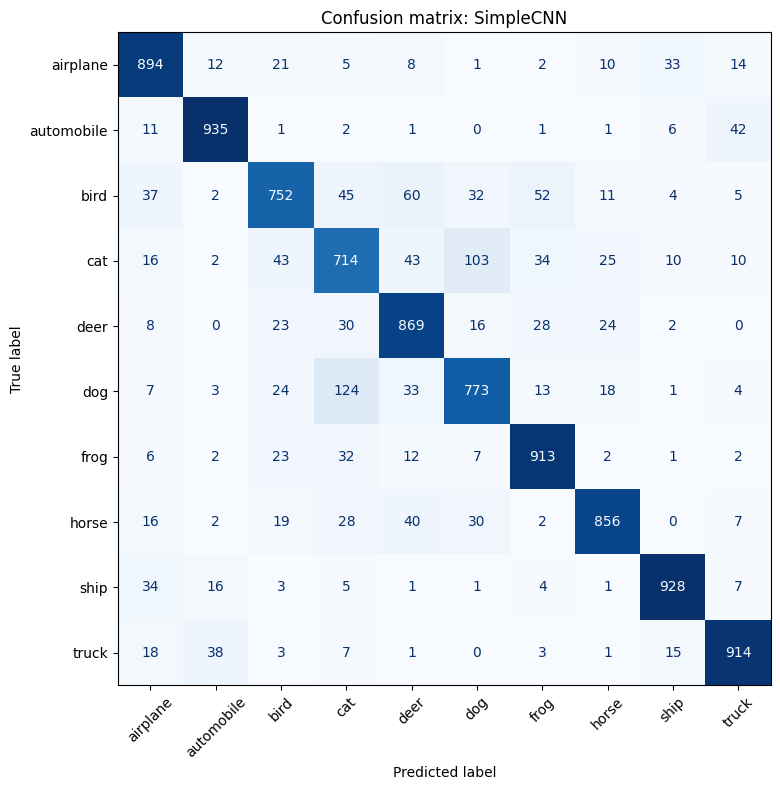

              precision    recall  f1-score   support

    airplane       0.85      0.89      0.87      1000
  automobile       0.92      0.94      0.93      1000
        bird       0.82      0.75      0.79      1000
         cat       0.72      0.71      0.72      1000
        deer       0.81      0.87      0.84      1000
         dog       0.80      0.77      0.79      1000
        frog       0.87      0.91      0.89      1000
       horse       0.90      0.86      0.88      1000
        ship       0.93      0.93      0.93      1000
       truck       0.91      0.91      0.91      1000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



In [ ]:
cnn = SimpleCNN(num_classes=num_classes).to(device)
cnn.load_state_dict(torch.load("results/SimpleCNN_best.pt", map_location=device))

cnn_loss, cnn_acc, cnn_true, cnn_pred = evaluate(cnn, val_loader, device)

print("SimpleCNN val loss:", cnn_loss)
print("SimpleCNN val acc:", cnn_acc)

plot_cm(cnn_true, cnn_pred, classes, "SimpleCNN")

print(classification_report(cnn_true, cnn_pred, target_names=classes))

with open("results/report_SimpleCNN.txt", "w", encoding="utf-8") as f:
    f.write(classification_report(cnn_true, cnn_pred, target_names=classes))


Как мы видим, на наших данных простая CNN модель, при равном числе эпох, справилась лучше, чем VSDD. Это может быть связано с недостаточным числом эпох для VSSD и простотой самого датасета. На маленьких картинках с легко различимыми классами простая cnn работает лучше (или обучается быстрее). Так же стоит учитывать, что мы использовали упрощенную реализацию VSSD, но тем не менее, она показала свою работоспособность